In [2]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
print("✅ Data loaded successfully!")

print("\n--- Data Preview ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

✅ Data loaded successfully!

--- Data Preview ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

--- Statistical Summary ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
from sklearn.preprocessing import StandardScaler

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features selected and scaled.")
print("First 5 rows of scaled data:")
print(X_scaled[:5])

✅ Features selected and scaled.
First 5 rows of scaled data:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


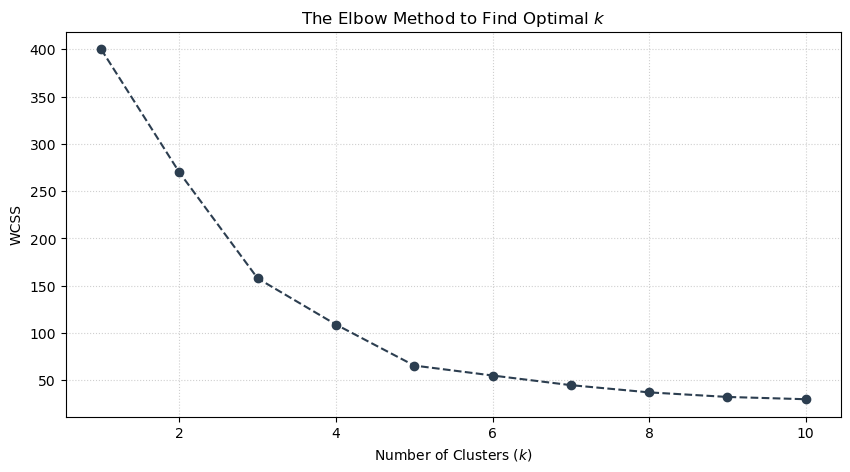

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')

wcss = []
for i in range(1, 11):
    # we use n_init=10 to be explicit and avoid future version warnings
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#2c3e50')
plt.title('The Elbow Method to Find Optimal $k$')
plt.xlabel('Number of Clusters ($k$)')
plt.ylabel('WCSS')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

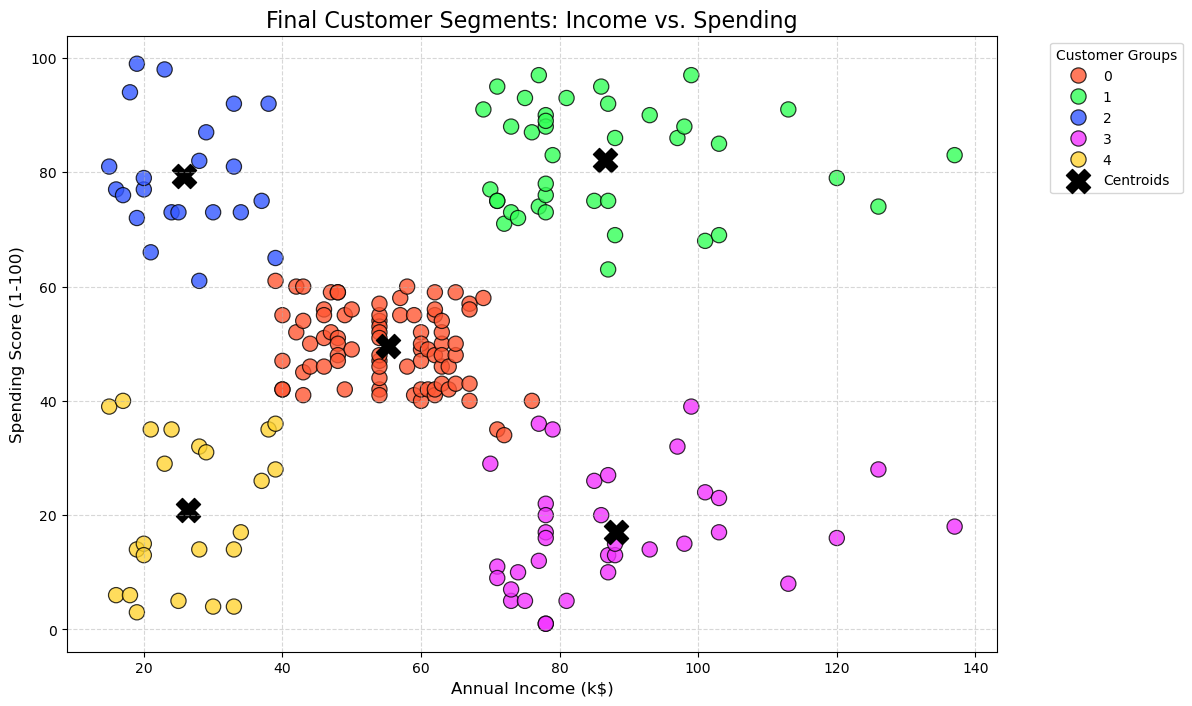

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

plt.figure(figsize=(12, 8))
colors = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#FFD433']

sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    data=df, 
    palette=colors, 
    s=120, 
    edgecolor='black', 
    alpha=0.8
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=300, 
    c='black', 
    marker='X', 
    label='Centroids'
)

plt.title('Final Customer Segments: Income vs. Spending', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Customer Groups', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()

In [9]:
analysis = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

analysis = analysis.sort_values(by='Spending Score (1-100)', ascending=False)

print("--- Final Cluster Profiles ---")
display(analysis)

--- Final Cluster Profiles ---


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
0,42.716049,55.296296,49.518519,81
4,45.217391,26.304348,20.913043,23
3,41.114286,88.200000,17.114286,35


In [10]:
def predict_customer_segment(income, spending_score):
    new_data_scaled = scaler.transform([[income, spending_score]])
    cluster_id = kmeans.predict(new_data_scaled)[0]

    profiles = {
        0: "Steady Middle (Average Income/Spend)",
        1: "Stars (High Income, High Spend) - Primary Target",
        2: "Impulse Buyers (Low Income, High Spend)",
        3: "Sensible Spenders (High Income, Low Spend)",
        4: "Budget Conscious (Low Income, Low Spend)"
    }

    print(f"--- Analysis for New Customer ---")
    print(f"Income: ${income}k | Spending Score: {spending_score}")
    print(f"Predicted Group: {profiles.get(cluster_id, 'Unknown')}")
    print(f"Recommended Strategy: { 'Apply Premium Marketing' if cluster_id == 1 else 'Apply Standard Engagement' }")

predict_customer_segment(90, 90)

--- Analysis for New Customer ---
Income: $90k | Spending Score: 90
Predicted Group: Stars (High Income, High Spend) - Primary Target
Recommended Strategy: Apply Premium Marketing


In [5]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_kmeans)

print(f"--- Model Quality Metrics ---")
print(f"Silhouette Score: {score:.4f}")

if score > 0.5:
    print("Interpretation: Strong structure. Your clusters are well-defined.")
elif score > 0.25:
    print("Interpretation: Fair structure. There is some overlap, but groups are distinct.")
else:
    print("Interpretation: Weak structure. The clusters are heavily overlapping.")

--- Model Quality Metrics ---
Silhouette Score: 0.5547
Interpretation: Strong structure. Your clusters are well-defined.


In [6]:
import joblib

joblib.dump(kmeans, 'mall_customer_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("✅ Files saved successfully:")
print("- mall_customer_model.pkl")
print("- scaler.pkl")

✅ Files saved successfully:
- mall_customer_model.pkl
- scaler.pkl


In [7]:
import joblib

loaded_model = joblib.load('mall_customer_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

new_observation = [[100, 80]]

new_obs_scaled = loaded_scaler.transform(new_observation)
prediction = loaded_model.predict(new_obs_scaled)

print(f"Machine Learning Handshake Successful!")
print(f"New Customer belongs to Cluster: {prediction[0]}")

Machine Learning Handshake Successful!
New Customer belongs to Cluster: 1
